In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [51]:
# K-Means
X, y_true = make_blobs(n_samples=500, centers=3, cluster_std=0.60, random_state=42)

In [52]:
df = pd.DataFrame(X, columns=['feature_1', 'feature_2'])
df.head()

,feature_1,feature_2
0,-6.190063,-7.302015
1,3.021747,1.940593
2,5.953761,1.488191
3,-2.744463,8.136177
4,5.360607,1.728324


In [53]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [54]:
wcss = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

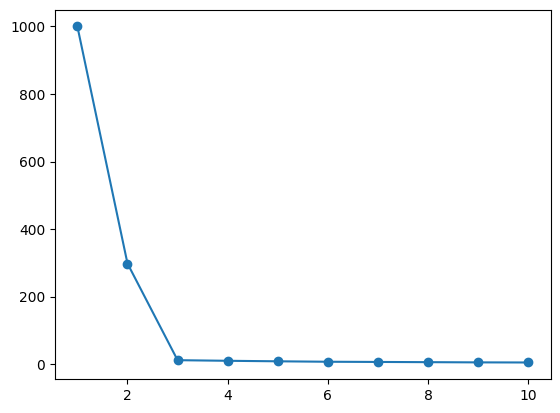

In [55]:
plt.plot(K_range, wcss, marker='o')

In [56]:
kmeans_final = KMeans(n_clusters=2, random_state=42)

In [57]:
cluster_labels = kmeans_final.fit_predict(X_scaled)

In [58]:
cluster_labels

array([1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,

In [59]:
df['cluster'] = cluster_labels

<Axes: xlabel='feature_1', ylabel='feature_2'>

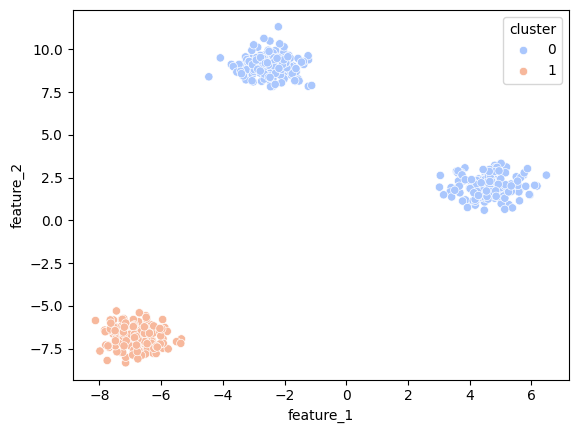

In [60]:
sns.scatterplot(data=df, x='feature_1', y='feature_2', hue='cluster', palette='coolwarm')

In [62]:
# DBSCAN
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN, KMeans

In [64]:
X, y = make_moons(n_samples=500, noise=0.05, random_state=42)
df = pd.DataFrame(X, columns=['feature_1', 'feature_2'])

In [67]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [68]:
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

In [69]:
df['kmeans_cluster'] = kmeans_labels

<Axes: xlabel='feature_1', ylabel='feature_2'>

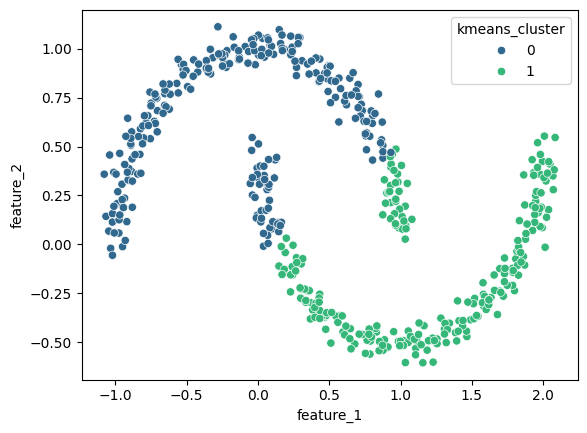

In [72]:
sns.scatterplot(data=df, x='feature_1', y='feature_2', hue='kmeans_cluster', palette='viridis')

In [73]:
dbscan = DBSCAN(eps=0.3, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

In [74]:
df['dbscan_cluster'] = dbscan_labels

<Axes: xlabel='feature_1', ylabel='feature_2'>

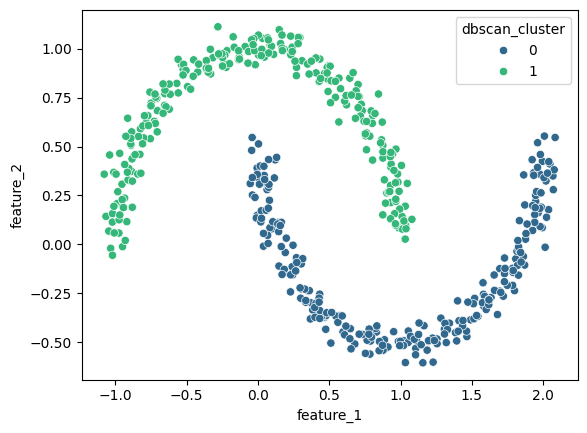

In [76]:
sns.scatterplot(data=df, x='feature_1', y='feature_2', hue='dbscan_cluster', palette='viridis')